# YOLOv8s-seg Training — LibraryAI Page Segmentation

Train a YOLOv8-small segmentation model to detect `page_left` and `page_right` in scanned document images.

**Dataset:** 252 images (63 originals × 4 rotations: 0°, 90°, 180°, 270°)  
**Split:** 176 train / 36 val / 40 test  
**Classes:** 0=page_left, 1=page_right (labels track physical page identity — NO class swap across rotations)  
**Model:** YOLOv8s-seg (Small — good capacity without overfitting on small dataset)  
**Post-processing:** validation only — model learns page identity from content cues

## 1. Setup & Install

In [1]:
!pip install ultralytics --quiet
!pip install Pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 100.9 MB/s eta 0:00:00


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
Setup complete ✅ (26 CPUs, 230.0 GB RAM, 43.1/235.7 GB disk)


## 2. Mount Google Drive & Extract Dataset

**Before running this cell:**
1. Zip your entire `Segmentation data augmentation` folder
2. Upload the zip to your Google Drive (root or a known folder)
3. Update the `ZIP_PATH` below to match

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

DATASET_DIR = "/content/drive/MyDrive/book_new"

print(f'Dataset directory: {DATASET_DIR}')
print(f'Contents: {os.listdir(DATASET_DIR)}')

Dataset directory: /content/drive/MyDrive/book_new
Contents: ['data.yaml', 'val.txt', 'train.txt', 'test.txt', 'labels', 'images']


## 3. Verify Dataset Structure

In [7]:
from pathlib import Path

ds = Path(DATASET_DIR)

for split in ['train', 'val', 'test']:
    img_dir = ds / 'images' / split
    lbl_dir = ds / 'labels' / split
    n_img = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    print(f'{split:5s}: {n_img} images, {n_lbl} labels')

# Show a sample label
sample = next((ds / 'labels' / 'train').glob('*.txt'))
print(f'\nSample label ({sample.name}):')
print(sample.read_text().strip())

train: 176 images, 176 labels
val  : 36 images, 36 labels
test : 40 images, 40 labels

Sample label (aub_aco003575_000021.txt):
1 0.493903 0.219192 0.744666 0.223711 0.750315 0.767766 0.490568 0.762489
0 0.241412 0.216741 0.493082 0.219542 0.490219 0.762508 0.232586 0.761999


## 4. Fix data.yaml Paths for Colab

The `data.yaml` uses relative paths. We rewrite it with absolute Colab paths.

In [8]:
import yaml

data_yaml_path = os.path.join(DATASET_DIR, 'data.yaml')

data_cfg = {
    'path': DATASET_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {
        0: 'page_left',
        1: 'page_right',
    }
}

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print('data.yaml written:')
print(open(data_yaml_path).read())

data.yaml written:
names:
  0: page_left
  1: page_right
path: /content/drive/MyDrive/book_new
test: images/test
train: images/train
val: images/val



## 6. Train YOLOv8s-seg

**Key hyperparameters:**
- `model`: yolov8s-seg (Small — 11.8M params, good for small datasets)
- `imgsz`: 2048 (matches spec's recommended resolution — preserves fine page boundaries)
- `epochs`: 150 (small dataset → more epochs, early stopping will catch overfitting)
- `patience`: 30 (early stopping patience)
- `batch`: 8 (A100 40GB handles 2048px comfortably)
- `augment`: True (default YOLOv8 augmentations: mosaic, mixup, hsv, flip etc.)

In [9]:
from ultralytics import YOLO

model = YOLO('yolov8s-seg.pt')

results = model.train(
    data=data_yaml_path,
    epochs=150,
    imgsz=2048,
    batch=8,
    patience=30,
    device=0,                # GPU
    workers=4,
    project='/content/runs',
    name='page_seg_v1',
    exist_ok=True,
    # Augmentation settings
    augment=True,
    mosaic=1.0,
    flipud=0.5,              # vertical flip (helps with rotated inputs)
    fliplr=0.5,              # horizontal flip
    degrees=5.0,             # small rotation augmentation
    scale=0.3,               # scale jitter
    # Regularization
    dropout=0.1,             # light dropout for small dataset
    weight_decay=0.0005,
    # Logging
    plots=True,
    save=True,
    save_period=25,          # save checkpoint every 25 epochs
)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/book_new/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=2048, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=page_seg_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

## 7. Training Results

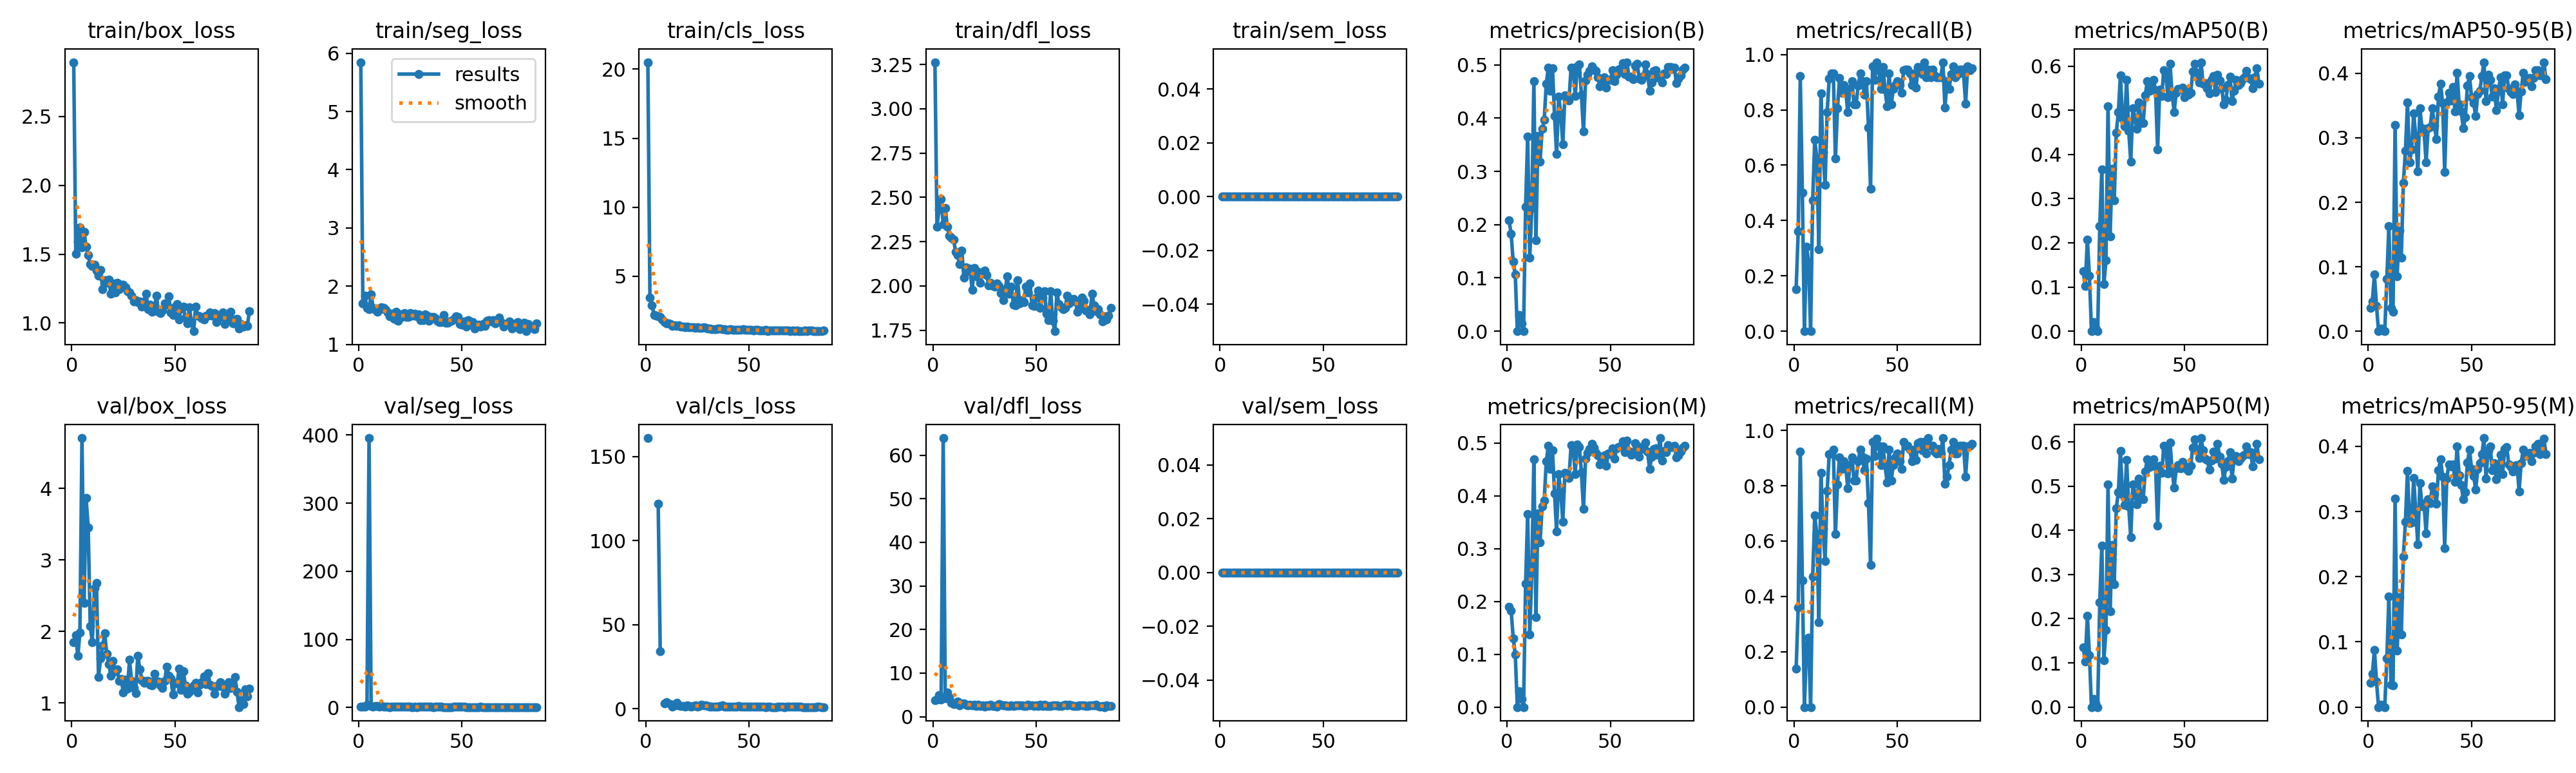

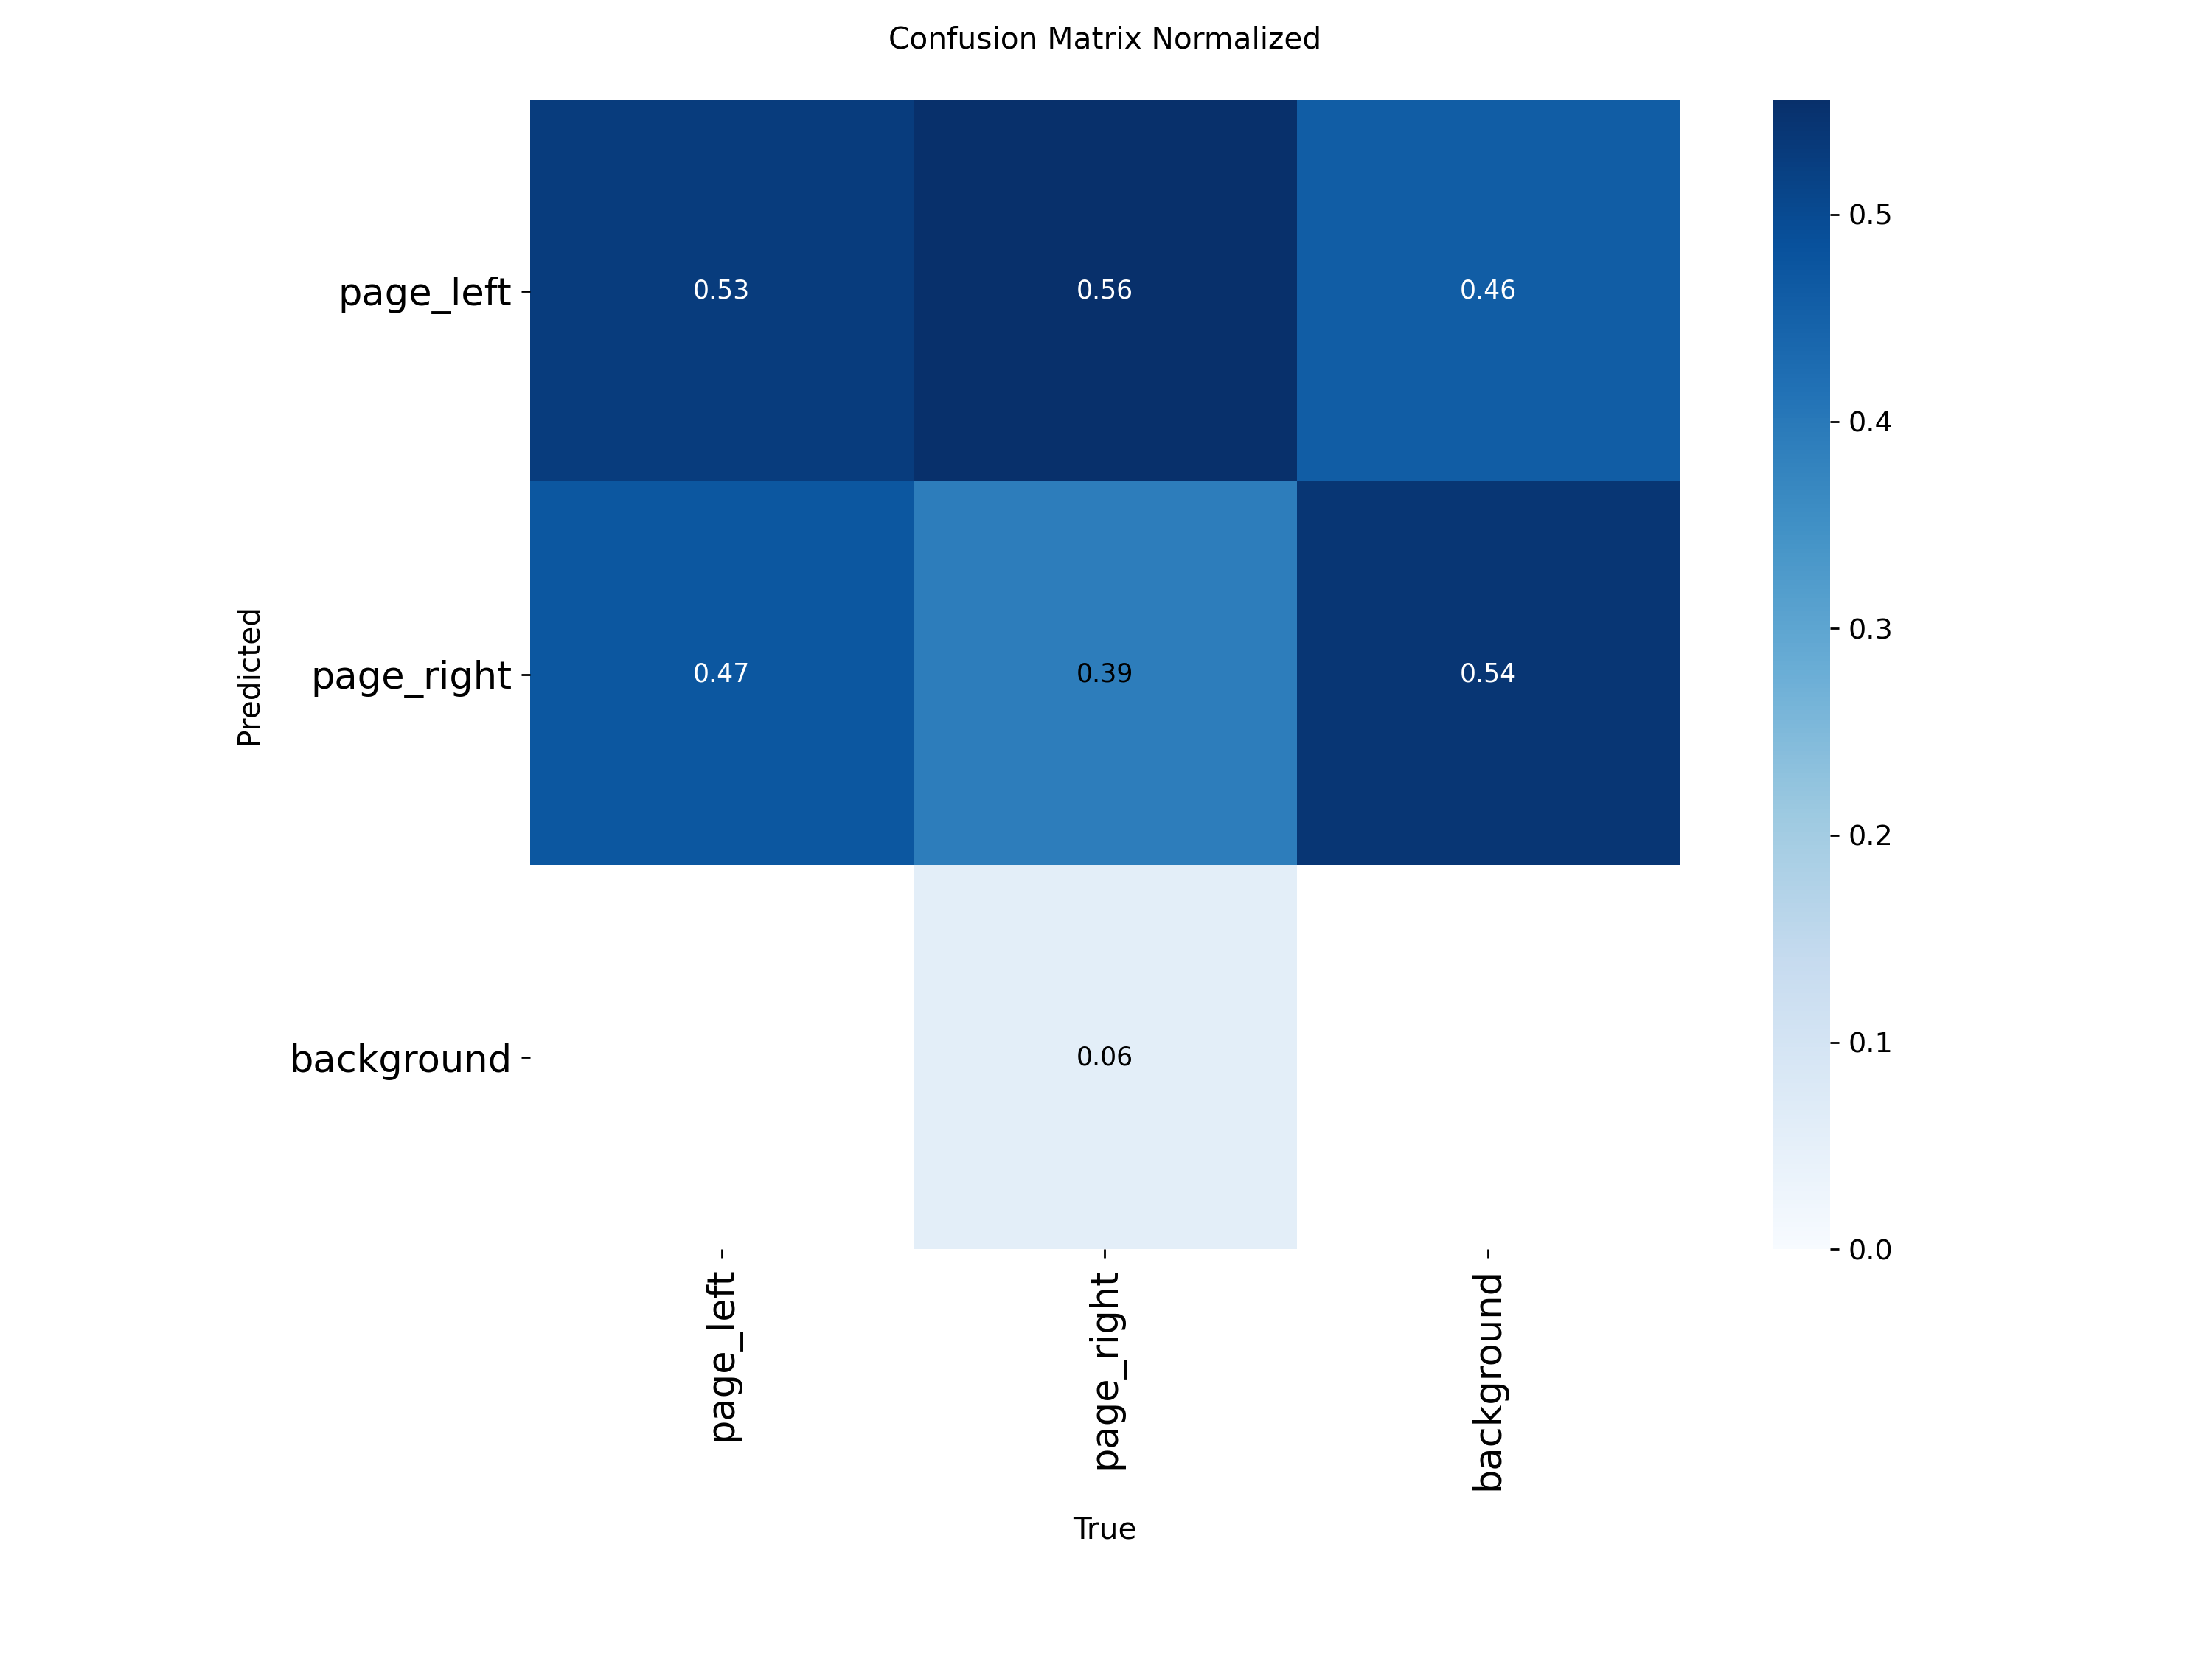

In [10]:
from IPython.display import Image as IPImage, display
import glob

run_dir = '/content/runs/page_seg_v1'

# Show training curves
results_img = os.path.join(run_dir, 'results.png')
if os.path.exists(results_img):
    display(IPImage(filename=results_img, width=900))

# Show confusion matrix
cm_img = os.path.join(run_dir, 'confusion_matrix_normalized.png')
if os.path.exists(cm_img):
    display(IPImage(filename=cm_img, width=600))

## 8. Validate on Val Set

In [11]:
# Load best checkpoint
best_model = YOLO(os.path.join(run_dir, 'weights', 'best.pt'))

# Validate
val_results = best_model.val(
    data=data_yaml_path,
    split='val',
    imgsz=2048,
    batch=8,
    device=0,
    plots=True,
)

print(f"\nmAP50     (mask): {val_results.seg.map50:.4f}")
print(f"mAP50-95  (mask): {val_results.seg.map:.4f}")
print(f"mAP50     (box):  {val_results.box.map50:.4f}")
print(f"mAP50-95  (box):  {val_results.box.map:.4f}")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 1390.5±30.8 MB/s, size: 7584.2 KB)
val: Scanning /content/drive/MyDrive/book_new/labels/val.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 13.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0it/s 2.6s
                   all         36         72      0.503      0.931      0.585      0.418      0.503      0.931      0.585      0.412
             page_left         36         36       0.51          1      0.529      0.381       0.51          1      0.529      0.375
            page_right         36         36      0.497      0.861      0.641      0.455      0.497      0.861      0.641      0.449
Speed: 19.3ms preproc

## 9. Evaluate on Test Set

In [12]:
test_results = best_model.val(
    data=data_yaml_path,
    split='test',
    imgsz=2048,
    batch=8,
    device=0,
    plots=True,
)

print(f"\nTest mAP50     (mask): {test_results.seg.map50:.4f}")
print(f"Test mAP50-95  (mask): {test_results.seg.map:.4f}")
print(f"Test mAP50     (box):  {test_results.box.map50:.4f}")
print(f"Test mAP50-95  (box):  {test_results.box.map:.4f}")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 4.5±4.0 MB/s, size: 7532.7 KB)
val: Scanning /content/drive/MyDrive/book_new/labels/test... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 1.4s/it 54.9s
val: New cache created: /content/drive/MyDrive/book_new/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 35.2s/it 2:56
                   all         40         76      0.437      0.852      0.467      0.339      0.436       0.85      0.453      0.332
             page_left         40         40      0.445      0.842      0.431      0.325      0.458      0.867      0.448      0.321
            page_right         36         36      0.428      0.861      0.502      0.354      0.415      0.833      0.458      0.343
Speed: 12.6ms preprocess, 5.6ms inference, 0

## Simple Inference on a Single Image

This section provides a streamlined code to perform inference on the specified TIFF image, loading the necessary components for visualization and prediction.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from ultralytics import YOLO
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

# --- Constants and Data Classes ---
CONFIDENCE_THRESHOLD = 0.50
CLASS_NAMES = {0: 'page_left', 1: 'page_right'}
CLASS_COLORS = {0: 'blue', 1: 'red'}

@dataclass
class PageDetection:
    class_id: int
    confidence: float
    polygon: np.ndarray

    @property
    def centroid(self) -> Tuple[float, float]:
        return float(self.polygon[:, 0].mean()), float(self.polygon[:, 1].mean())

@dataclass
class PostProcessResult:
    detections: List[PageDetection]
    page_count: int
    split_required: bool
    layout: str = "unknown"
    needs_review: bool = False
    warnings: List[str] = field(default_factory=list)

# --- Helper Functions ---
def classify_layout(det_a, det_b):
    cx_a, cy_a = det_a.centroid
    cx_b, cy_b = det_b.centroid
    dx, dy = abs(cx_a - cx_b), abs(cy_a - cy_b)
    if dx < 1e-6 and dy < 1e-6:
        return "ambiguous"
    return "horizontal" if dx >= dy else "vertical"

def validate_page_assignments(detections):
    warnings = []
    needs_review = False

    if len(detections) == 0:
        return PostProcessResult([], 0, False, layout="empty", needs_review=True, warnings=["No pages detected."])
    if len(detections) == 1:
        det = detections[0]
        nr = det.confidence < CONFIDENCE_THRESHOLD
        w = [f"Low confidence ({det.confidence:.2f})."] if nr else []
        return PostProcessResult(detections, 1, False, layout="single", needs_review=nr, warnings=w)
    if len(detections) > 2:
        warnings.append(f"Expected 1-2 pages, got {len(detections)}. Using top 2.")
        detections = sorted(detections, key=lambda d: d.confidence, reverse=True)[:2]

    det_a, det_b = detections
    layout = classify_layout(det_a, det_b)

    classes = {det_a.class_id, det_b.class_id}
    if classes != {0, 1}:
        needs_review = True
        warnings.append(f"Duplicate classes: both are class {det_a.class_id}. Needs review.")

    min_conf = min(det_a.confidence, det_b.confidence)
    if min_conf < CONFIDENCE_THRESHOLD:
        needs_review = True
        warnings.append(f"Low confidence ({min_conf:.2f}). Needs review.")

    ordered = sorted(detections, key=lambda d: d.class_id)
    return PostProcessResult(ordered, 2, True, layout, needs_review, warnings)

def parse_yolo_seg_results(results, conf_threshold=0.25):
    detections = []
    if results.masks is None:
        return detections
    for mask_xy, box in zip(results.masks.xyn, results.boxes):
        conf = float(box.conf[0])
        if conf < conf_threshold:
            continue
        detections.append(PageDetection(
            class_id=int(box.cls[0]),
            confidence=conf,
            polygon=np.array(mask_xy),
        ))
    return detections

def predict_pages(model, image_path, imgsz=2048, conf=0.25):
    results = model(str(image_path), imgsz=imgsz, device=0, verbose=False)[0]
    detections = parse_yolo_seg_results(results, conf_threshold=conf)
    return validate_page_assignments(detections)

print("Inference functions and constants loaded.")


Inference functions and constants loaded.


Performing inference on: aub_aco003575_000007_rot90.tif


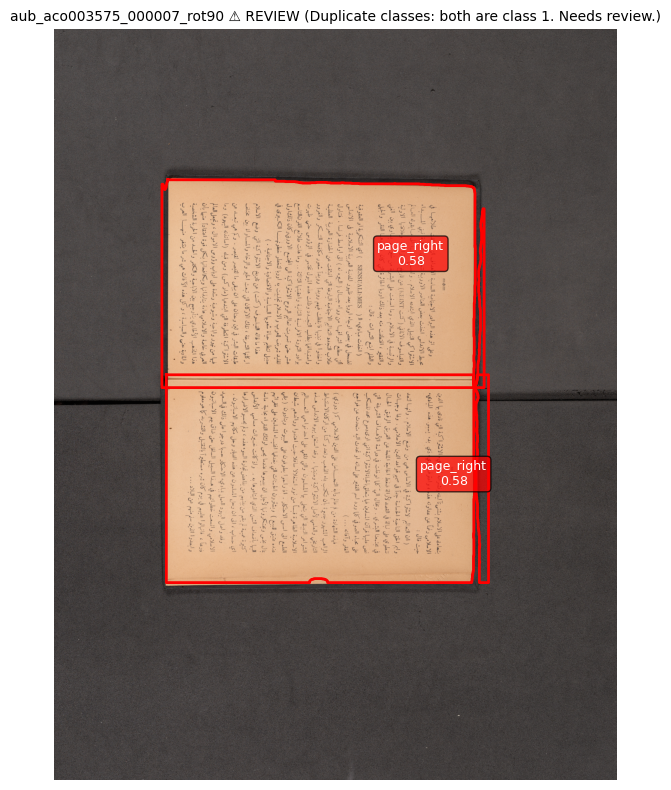


Inference Details for aub_aco003575_000007_rot90.tif:
  Page Count: 2
  Layout: vertical
  Needs Review: True
  Warnings: Duplicate classes: both are class 1. Needs review.
  Detection 1: page_right, Confidence: 0.5810
  Detection 2: page_right, Confidence: 0.5772


In [24]:
# --- Load the trained model ---
# Assuming 'run_dir' is '/content/runs/page_seg_v1' based on previous execution
run_dir = '/content/runs/page_seg_v1'
best_model_path = Path(run_dir) / 'weights' / 'best.pt'
best_model = YOLO(str(best_model_path))

# --- Define the image path for inference ---
image_for_inference = Path('/content/aub_aco003575_000007_rot90.tif')

if not image_for_inference.exists():
    print(f"Error: Image not found at {image_for_inference}")
else:
    print(f"Performing inference on: {image_for_inference.name}")

    # --- Run inference ---
    inference_result = predict_pages(best_model, image_for_inference)

    # --- Visualize the results ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    img = Image.open(image_for_inference)
    w, h = img.size
    ax.imshow(img)

    for det in inference_result.detections:
        poly = det.polygon * np.array([w, h])
        poly_closed = np.vstack([poly, poly[0]]) # Close the polygon for plotting
        color = CLASS_COLORS[det.class_id]
        ax.plot(poly_closed[:, 0], poly_closed[:, 1], '-', color=color, linewidth=2)
        cx, cy = det.centroid
        ax.text(cx * w, cy * h, f"{CLASS_NAMES[det.class_id]}\n{det.confidence:.2f}",
                color='white', fontsize=9, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7))

    title = image_for_inference.stem
    if inference_result.needs_review:
        title += ' ⚠ REVIEW'
    if inference_result.warnings:
        title += ' (' + ', '.join(inference_result.warnings) + ')'
    ax.set_title(title, fontsize=10)
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\nInference Details for {image_for_inference.name}:")
    print(f"  Page Count: {inference_result.page_count}")
    print(f"  Layout: {inference_result.layout}")
    print(f"  Needs Review: {inference_result.needs_review}")
    if inference_result.warnings:
        print(f"  Warnings: {', '.join(inference_result.warnings)}")
    for i, det in enumerate(inference_result.detections):
        print(f"  Detection {i+1}: {CLASS_NAMES[det.class_id]}, Confidence: {det.confidence:.4f}")
